# Eval loss vs human by rating_bin (13 bins + ALL)
Computes per-bin loss metrics for human vs model moves using Stockfish evals, exports a row-level debug CSV, and plots both absolute metrics and **delta vs human** (positive = model better).

**Conventions**
- `loss_cp` is **mover-POV centipawn loss** (POV sign applied using `player_color`).
- `loss_wr` / `blunder` are computed on winrate in [0,1] with **no POV sign**.


In [5]:
# === Imports ===
from __future__ import annotations

import importlib.util
import subprocess
import sys
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [6]:
# === Paths / config ===
REPO_ROOT = "/home/jovyan/artem/chess-fraud"
print("REPO_ROOT:", REPO_ROOT)

INPUT_CSV = REPO_ROOT / Path("data/processed/chess_fraud_synth_extended.csv")
print("INPUT_CSV:", INPUT_CSV)

CP_TO_WINRATE_PY = REPO_ROOT / "new_notebooks/cp_to_winrate.py"
print("CP_TO_WINRATE_PY:", CP_TO_WINRATE_PY)

OUT_DIR = REPO_ROOT / Path("reports/move_level/03_strength_advantage")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# Columns
RATING_BIN_COL = "rating_bin"
EVAL_BEFORE_COL = "eval_before"
EVAL_AFTER_COL = "eval_after"

# Selection rule (same as other experiments)
HALF_MOVE_COL = "half_move"
PLAYER_COLOR_COL = "player_color"

# Optional extra columns (written to debug CSV if present)
OPTIONAL_BASE_COLS = [
    "game_id", "player", "opponent", "player_elo", "opponent_elo", "half_move", "player_color", "rating_bin"
]

# Streaming
CHUNKSIZE = 200_000

# Eval clipping (centipawns)
EVAL_CLIP_CP = 1000.0

# If True: apply a common non-null mask across [rating_bin, eval_before, eval_after, all model eval cols]
# so denominators are identical across columns (models/human).
COMMON_NONNULL_MASK = True

# Blunder definition (winrate drop threshold)
BLUNDER_WR_DROP = 0.10

# Debug row-level export (eligible rows only). Set to None to export ALL eligible rows (can be huge).
DEBUG_OUT_CSV = OUT_DIR / "debug_rows_eval_loss.csv"
DEBUG_MAX_ROWS: int | None = 1000

REPO_ROOT: /home/jovyan/artem/humanlike
INPUT_CSV: /home/jovyan/artem/humanlike/data/processed/13bins_small/04_dataset_with_stockfish_15_full.csv
CP_TO_WINRATE_PY: /home/jovyan/artem/humanlike/new_notebooks/cp_to_winrate.py
OUT_DIR: /home/jovyan/artem/humanlike/notebooks/reports/expr_eval_loss_by_bin


In [7]:
# === Utilities ===
def select_eligible_rows(df: pd.DataFrame) -> pd.Series:
    '''Eligibility mask (reused across all experiments).

    Rule:
      half_move > 20 AND (
        (player_color == 'white' AND half_move % 2 == 1) OR
        (player_color == 'black' AND half_move % 2 == 0)
      )
    '''
    half_move = df[HALF_MOVE_COL].to_numpy()
    player_color = df[PLAYER_COLOR_COL].astype("string")

    return (half_move > 20) & (
        ((player_color == "white") & (half_move % 2 == 1))
        | ((player_color == "black") & (half_move % 2 == 0))
    )


def build_fen_col_to_model(columns: list[str]) -> dict[str, str]:
    '''Map FEN columns to model names.'''
    out: dict[str, str] = {}
    if "fen_after" in columns:
        out["fen_after"] = "human"
    for c in columns:
        if not c.startswith("fen_"):
            continue
        if c in ("fen_before", "fen_after"):
            continue
        out[c] = c.replace("fen_", "", 1)
    return out


def _model_sort_key(name: str) -> tuple:
    if name == "human":
        return (0, 0)
    m = re.match(r"^(maia1|maia2)_(\d+)$", name)
    if m:
        fam, r = m.group(1), int(m.group(2))
        return (1 if fam == "maia1" else 2, r)
    m = re.match(r"^lc0_(\d+)$", name)
    if m:
        return (3, int(m.group(1)))
    m = re.match(r"^stockfish_(\d+)$", name)
    if m:
        return (4, int(m.group(1)))
    return (5, name)


def _rating_bin_sort_key(b: str) -> tuple:
    if b == "ALL":
        return (10**9, 10**9, b)
    m = re.match(r"^lt_(\d+)$", b)
    if m:
        return (-1, int(m.group(1)), b)
    m = re.match(r"^(\d+)_(\d+)$", b)
    if m:
        return (int(m.group(1)), int(m.group(2)), b)
    m = re.match(r"^gt_(\d+)$", b)
    if m:
        return (10**8, int(m.group(1)), b)
    return (10**7, 10**7, b)


def load_cp_to_winrate_module(path: Path):
    spec = importlib.util.spec_from_file_location("cp_to_winrate", path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Failed to import cp_to_winrate from: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)  # type: ignore[attr-defined]
    return module


def build_wr_lookup(cp_lookup: dict[float, float]) -> np.ndarray:
    arr = np.full(201, np.nan, dtype=np.float64)
    for k, v in cp_lookup.items():
        idx = int(round((float(k) + 10.0) * 10.0))
        if 0 <= idx < arr.shape[0]:
            arr[idx] = float(v)
    return arr


def eval_cp_to_winrate_vec(eval_cp: np.ndarray, lookup: np.ndarray) -> np.ndarray:
    x = np.asarray(eval_cp, dtype=np.float64)
    x = np.clip(x, -EVAL_CLIP_CP, EVAL_CLIP_CP) / 100.0
    x_adj = np.trunc(x * 10.0) / 10.0
    idx = (np.trunc(x_adj * 10.0).astype(np.int64) + 100)
    out = np.full(x_adj.shape, np.nan, dtype=np.float64)
    ok = np.isfinite(x_adj) & (idx >= 0) & (idx < lookup.shape[0])
    out[ok] = lookup[idx[ok]]
    return out


def mean_std_from_sums(n: np.ndarray, s: np.ndarray, ss: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n = n.astype(np.float64)
    mean = np.full_like(s, np.nan, dtype=np.float64)
    std = np.full_like(s, np.nan, dtype=np.float64)
    ok = n > 0
    mean[ok] = s[ok] / n[ok]
    var = np.full_like(s, np.nan, dtype=np.float64)
    var[ok] = ss[ok] / n[ok] - mean[ok] * mean[ok]
    var = np.maximum(var, 0.0)
    std[ok] = np.sqrt(var[ok])
    return mean, std


def plot_metric_heatmap(
    table: pd.DataFrame,
    *,
    title: str,
    out_path: Path | None,
    vmin: float | None = None,
    vmax: float | None = None,
    fmt: str = "auto",
    figsize: tuple[int, int] | None = None,
    cmap: str = "Blues",
    center: float | None = None,
) -> None:
    n_rows, n_cols = table.shape
    if figsize is None:
        w = min(28, max(10, int(0.60 * n_cols)))
        h = min(20, max(6, int(0.45 * n_rows)))
        figsize = (w, h)

    mat = table.to_numpy(dtype=float)
    finite = mat[np.isfinite(mat)]
    if finite.size == 0:
        print("[plot_metric_heatmap] All values are NaN; skip:", title)
        return

    if vmin is None or vmax is None:
        if center is None:
            if vmin is None:
                vmin = float(np.nanpercentile(finite, 5))
            if vmax is None:
                vmax = float(np.nanpercentile(finite, 95))
        else:
            span = float(np.nanpercentile(np.abs(finite - center), 95))
            if vmin is None:
                vmin = center - span
            if vmax is None:
                vmax = center + span

    assert vmin is not None and vmax is not None
    if vmin == vmax:
        vmax = vmin + 1e-6

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, interpolation="nearest", aspect="auto")

    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(table.columns.tolist(), rotation=45, ha="right", color="black")
    ax.set_yticklabels(table.index.tolist(), color="black")
    ax.tick_params(axis="both", colors="black", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, color="black", pad=10)

    def _format(v: float) -> str:
        if not np.isfinite(v):
            return ""
        if fmt == "pct":
            return f"{int(round(v * 100))}"
        if fmt == "pp":
            return f"{v:+.3f}"
        if fmt == "cp":
            return f"{v:+.1f}"
        return f"{v:.3g}"

    for i in range(n_rows):
        for j in range(n_cols):
            v = mat[i, j]
            if np.isfinite(v):
                ax.text(j, i, _format(float(v)), ha="center", va="center", fontsize=8, color="black")

    fig.tight_layout(pad=0.6)
    if out_path is not None:
        fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()

In [8]:
# === Load winrate lookup ===
cpmod = load_cp_to_winrate_module(CP_TO_WINRATE_PY)
wr_lookup = build_wr_lookup(cpmod.cpLookup)
assert wr_lookup.shape == (201,)
print("wr_lookup[cp=0.0 pawns] =", wr_lookup[100])

wr_lookup[cp=0.0 pawns] = 0.5606402112975601


In [9]:
# === Streaming stats by rating bin ===
@dataclass
class Agg:
    n_cp: np.ndarray
    sum_cp: np.ndarray
    sumsq_cp: np.ndarray
    n_wr: np.ndarray
    sum_wr: np.ndarray
    sumsq_wr: np.ndarray
    n_blunder: np.ndarray
    denom_common: int


def eval_loss_stats_by_bin_from_csv(
    input_csv: Path,
    *,
    rating_bin_col: str,
    eval_before_col: str,
    eval_after_col: str,
    chunksize: int,
    common_nonnull_mask: bool,
    wr_lookup: np.ndarray,
    verbose: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame, pd.DataFrame]:
    header_cols = pd.read_csv(input_csv, nrows=0).columns.tolist()

    required = [HALF_MOVE_COL, PLAYER_COLOR_COL, rating_bin_col, eval_before_col, eval_after_col]
    for c in required:
        if c not in header_cols:
            raise ValueError(f"Missing required column: {c}")

    fen_col_to_model = build_fen_col_to_model(header_cols)

    target_pairs: list[tuple[str, str]] = [(eval_after_col, "human")]
    dropped: list[str] = []
    for fen_col, model_name in fen_col_to_model.items():
        if model_name == "human":
            continue
        suffix = fen_col.replace("fen_", "", 1)
        eval_col = f"eval_{suffix}"
        if eval_col in header_cols:
            target_pairs.append((eval_col, model_name))
        else:
            dropped.append(model_name)

    target_pairs.sort(key=lambda x: _model_sort_key(x[1]))
    target_eval_cols = [c for c, _m in target_pairs]
    model_names = [m for _c, m in target_pairs]

    if len(target_eval_cols) <= 1:
        raise ValueError("No model eval_* columns found that match any fen_* column (besides eval_after/human).")

    if dropped:
        print("[warn] Dropped models with missing eval_<suffix>:", sorted(set(dropped), key=_model_sort_key))

    mapping_df = pd.DataFrame({"eval_col": target_eval_cols, "model": model_names})

    usecols = [HALF_MOVE_COL, PLAYER_COLOR_COL, rating_bin_col, eval_before_col] + target_eval_cols

    by_bin: dict[str, Agg] = {}

    def _get_agg(b: str) -> Agg:
        if b not in by_bin:
            z_i = np.zeros(len(model_names), dtype=np.int64)
            z_f = np.zeros(len(model_names), dtype=np.float64)
            by_bin[b] = Agg(
                n_cp=z_i.copy(), sum_cp=z_f.copy(), sumsq_cp=z_f.copy(),
                n_wr=z_i.copy(), sum_wr=z_f.copy(), sumsq_wr=z_f.copy(),
                n_blunder=z_i.copy(), denom_common=0
            )
        return by_bin[b]

    total = _get_agg("ALL__TOTAL__")

    it = pd.read_csv(input_csv, usecols=usecols, chunksize=chunksize)
    pbar = tqdm(it, desc="Scan CSV chunks", unit="chunk") if verbose else it

    for chunk in pbar:
        mask = select_eligible_rows(chunk) & chunk[rating_bin_col].notna()
        if not mask.any():
            continue

        sub = chunk.loc[mask, [rating_bin_col, PLAYER_COLOR_COL, eval_before_col] + target_eval_cols]

        if common_nonnull_mask:
            nn = sub.notna().all(axis=1)
            if not nn.any():
                continue
            sub = sub.loc[nn]

        if sub.empty:
            continue

        for b_raw, g in sub.groupby(rating_bin_col, sort=False):
            b = str(b_raw)

            sign = np.where(g[PLAYER_COLOR_COL].astype("string").to_numpy() == "white", 1.0, -1.0)

            before = g[eval_before_col].to_numpy(dtype=np.float64, copy=False)
            targets = g[target_eval_cols].to_numpy(dtype=np.float64, copy=False)

            before_clip = np.clip(before, -EVAL_CLIP_CP, EVAL_CLIP_CP)
            targets_clip = np.clip(targets, -EVAL_CLIP_CP, EVAL_CLIP_CP)

            loss_cp = (before_clip[:, None] - targets_clip) * sign[:, None]

            wr_before = eval_cp_to_winrate_vec(before_clip, wr_lookup)
            wr_targets = eval_cp_to_winrate_vec(targets_clip, wr_lookup)
            loss_wr = wr_before[:, None] - wr_targets  # NO POV sign

            agg = _get_agg(b)
            n_rows = int(len(g))
            agg.denom_common += n_rows
            total.denom_common += n_rows

            # CP
            m_cp = np.isfinite(loss_cp)
            loss_cp0 = np.nan_to_num(loss_cp, nan=0.0, posinf=0.0, neginf=0.0)
            n_cp = m_cp.sum(axis=0, dtype=np.int64)
            s_cp = loss_cp0.sum(axis=0, dtype=np.float64)
            ss_cp = (loss_cp0 * loss_cp0).sum(axis=0, dtype=np.float64)
            agg.n_cp += n_cp; agg.sum_cp += s_cp; agg.sumsq_cp += ss_cp
            total.n_cp += n_cp; total.sum_cp += s_cp; total.sumsq_cp += ss_cp

            # WR
            m_wr = np.isfinite(loss_wr)
            loss_wr0 = np.nan_to_num(loss_wr, nan=0.0, posinf=0.0, neginf=0.0)
            n_wr = m_wr.sum(axis=0, dtype=np.int64)
            s_wr = loss_wr0.sum(axis=0, dtype=np.float64)
            ss_wr = (loss_wr0 * loss_wr0).sum(axis=0, dtype=np.float64)
            agg.n_wr += n_wr; agg.sum_wr += s_wr; agg.sumsq_wr += ss_wr
            total.n_wr += n_wr; total.sum_wr += s_wr; total.sumsq_wr += ss_wr

            bl = (loss_wr > BLUNDER_WR_DROP) & m_wr
            n_bl = bl.sum(axis=0, dtype=np.int64)
            agg.n_blunder += n_bl
            total.n_blunder += n_bl

    bins = [b for b in by_bin.keys() if b != "ALL__TOTAL__"]
    if not bins or total.denom_common == 0:
        raise ValueError("No eligible rows found (after non-null filtering).")

    bins_sorted = sorted(bins, key=_rating_bin_sort_key)

    def _row_from_agg(agg: Agg) -> dict[str, np.ndarray]:
        mean_cp, std_cp = mean_std_from_sums(agg.n_cp, agg.sum_cp, agg.sumsq_cp)
        mean_wr, std_wr = mean_std_from_sums(agg.n_wr, agg.sum_wr, agg.sumsq_wr)
        bl_rate = np.full(len(model_names), np.nan, dtype=np.float64)
        ok = agg.n_wr > 0
        bl_rate[ok] = agg.n_blunder[ok].astype(np.float64) / agg.n_wr[ok].astype(np.float64)
        return {"cp_mean": mean_cp, "cp_std": std_cp, "wr_mean": mean_wr, "wr_std": std_wr, "blunder_rate": bl_rate}

    idx, denoms = [], []
    rows = {k: [] for k in ["cp_mean","cp_std","wr_mean","wr_std","blunder_rate"]}

    for b in bins_sorted:
        r = _row_from_agg(by_bin[b])
        for k in rows: rows[k].append(r[k])
        idx.append(b); denoms.append(by_bin[b].denom_common)

    r_all = _row_from_agg(total)
    for k in rows: rows[k].append(r_all[k])
    idx.append("ALL"); denoms.append(total.denom_common)

    tables = {
        "cp_mean": pd.DataFrame(np.vstack(rows["cp_mean"]), index=idx, columns=model_names),
        "cp_std": pd.DataFrame(np.vstack(rows["cp_std"]), index=idx, columns=model_names),
        "wr_mean": pd.DataFrame(np.vstack(rows["wr_mean"]), index=idx, columns=model_names),
        "wr_std": pd.DataFrame(np.vstack(rows["wr_std"]), index=idx, columns=model_names),
        "blunder_rate": pd.DataFrame(np.vstack(rows["blunder_rate"]), index=idx, columns=model_names),
    }
    denom_df = pd.DataFrame({"denom_common": denoms}, index=idx)
    return tables, mapping_df, denom_df

In [10]:
# === Compute tables ===
tables, mapping_df, denom_df = eval_loss_stats_by_bin_from_csv(
    INPUT_CSV,
    rating_bin_col=RATING_BIN_COL,
    eval_before_col=EVAL_BEFORE_COL,
    eval_after_col=EVAL_AFTER_COL,
    chunksize=CHUNKSIZE,
    common_nonnull_mask=COMMON_NONNULL_MASK,
    wr_lookup=wr_lookup,
    verbose=True,
)

display(mapping_df.head(30))
display(denom_df)

mapping_df.to_csv(OUT_DIR / "eval_col_to_model.csv", index=False)
denom_df.to_csv(OUT_DIR / "denom_by_rating_bin.csv")

for k, df in tables.items():
    df.to_csv(OUT_DIR / f"{k}.csv")
    print("saved", k)

display(tables["cp_mean"])

Scan CSV chunks: 0chunk [00:00, ?chunk/s]

,eval_col,model
0,eval_after,human
1,eval_maia1_1100,maia1_1100
2,eval_maia1_1200,maia1_1200
3,eval_maia1_1300,maia1_1300
4,eval_maia1_1400,maia1_1400
5,eval_maia1_1500,maia1_1500
6,eval_maia1_1600,maia1_1600
7,eval_maia1_1700,maia1_1700
8,eval_maia1_1800,maia1_1800
9,eval_maia1_1900,maia1_1900


,denom_common
lt_1100,33486
1100_1200,33440
1200_1300,34746
1300_1400,34476
1400_1500,33746
1500_1600,34918
1600_1700,34358
1700_1800,35457
1800_1900,35027
1900_2000,35736


saved cp_mean
saved cp_std
saved wr_mean
saved wr_std
saved blunder_rate


,human,maia1_1100,maia1_1200,maia1_1300,maia1_1400,maia1_1500,maia1_1600,maia1_1700,maia1_1800,maia1_1900,...,character_Odirovski_2499,character_Quillotamaster_2405,character_Smalldoc_2254,character_alkhawaja111_2217,character_fuegodejavu_2215,character_jozarov_2323,character_lindenice_2272,character_nrm18_2369,character_oberschlumpf_2261,character_rmnp_2284
lt_1100,78.600938,51.355104,49.725766,49.744401,48.701487,47.380398,47.678970,45.869976,46.409126,46.489518,...,53.713104,53.630652,53.013289,51.946037,52.800962,53.865168,51.712328,52.151974,53.636445,52.657140
1100_1200,72.133433,53.177422,51.730233,49.868331,48.891388,48.063517,47.326465,47.955502,47.138218,46.489563,...,54.151645,54.251645,54.468870,52.787410,53.270096,55.215879,52.749611,53.781220,54.494228,53.524342
1200_1300,68.847493,53.045387,52.391182,51.690353,49.372877,48.662753,48.223853,47.052668,47.672135,46.535083,...,53.184971,54.306539,53.795804,53.184338,54.095493,54.712370,52.927733,53.058453,54.811086,53.519743
1300_1400,64.713598,51.850795,49.964729,48.859729,47.661156,46.706520,45.571615,45.054038,45.820455,44.610686,...,52.025119,53.902686,53.299948,52.442598,52.432736,53.327996,51.895522,51.461712,52.937058,51.962612
1400_1500,63.815593,53.166390,51.640372,50.615895,49.223375,47.132519,46.574705,46.974101,46.882060,46.218189,...,52.947905,53.930629,54.731198,52.785901,53.647099,54.449861,52.808600,52.838855,53.585373,52.923754
1500_1600,61.587605,54.724497,52.828541,50.644109,49.143794,48.073744,47.358669,47.063950,46.310470,46.031560,...,54.000086,54.615757,54.495590,53.961596,54.859900,55.426485,53.203076,54.483304,54.395097,53.157741
1600_1700,59.197538,55.829181,53.121078,51.440625,49.593050,48.442372,47.916439,46.881396,47.290471,46.574160,...,54.418389,55.111182,55.079690,54.130304,54.327609,54.735084,53.735782,54.631905,55.159352,53.773706
1700_1800,58.695490,55.511493,53.910737,51.759032,50.149110,48.603492,49.058070,48.412443,48.234820,47.082974,...,55.036156,55.699044,56.047692,54.926390,54.897284,56.060609,54.091040,54.880390,55.878980,54.670107
1800_1900,55.496588,58.717104,56.933251,55.168242,51.863848,50.662546,50.313158,49.689154,49.820795,48.008222,...,55.637879,56.563166,57.788449,56.537928,56.384104,57.450738,55.389014,55.512062,57.393639,55.297570
1900_2000,52.154886,59.134822,57.061507,54.107846,52.798215,51.093379,50.148953,49.131800,49.516818,48.478873,...,56.030473,58.002490,58.847017,56.336551,58.206542,58.783468,56.311059,57.148086,58.158719,57.250756


In [11]:
# === Delta vs human (positive = model better) ===
def delta_vs_human(table: pd.DataFrame) -> pd.DataFrame:
    if "human" not in table.columns:
        raise ValueError("Expected 'human' column in table.")
    human = table["human"]
    out = table.copy()
    for c in out.columns:
        out[c] = (human - out[c]).astype(float)
    out["human"] = 0.0
    return out

delta_tables = {
    "cp_mean_delta": delta_vs_human(tables["cp_mean"]),
    "wr_mean_delta": delta_vs_human(tables["wr_mean"]),
    "blunder_rate_delta": delta_vs_human(tables["blunder_rate"]),
}

for k, df in delta_tables.items():
    df.to_csv(OUT_DIR / f"{k}.csv")
    print("saved", k)

display(delta_tables["cp_mean_delta"])

saved cp_mean_delta
saved wr_mean_delta
saved blunder_rate_delta


,human,maia1_1100,maia1_1200,maia1_1300,maia1_1400,maia1_1500,maia1_1600,maia1_1700,maia1_1800,maia1_1900,...,character_Odirovski_2499,character_Quillotamaster_2405,character_Smalldoc_2254,character_alkhawaja111_2217,character_fuegodejavu_2215,character_jozarov_2323,character_lindenice_2272,character_nrm18_2369,character_oberschlumpf_2261,character_rmnp_2284
lt_1100,0.0,27.245834,28.875172,28.856537,29.899451,31.220540,30.921967,32.730962,32.191812,32.111420,...,24.887834,24.970286,25.587649,26.654901,25.799976,24.735770,26.888610,26.448964,24.964493,25.943797
1100_1200,0.0,18.956011,20.403200,22.265102,23.242045,24.069916,24.806968,24.177931,24.995215,25.643870,...,17.981788,17.881788,17.664563,19.346023,18.863337,16.917554,19.383822,18.352213,17.639205,18.609091
1200_1300,0.0,15.802107,16.456312,17.157140,19.474616,20.184741,20.623640,21.794825,21.175358,22.312410,...,15.662522,14.540954,15.051689,15.663155,14.752000,14.135123,15.919761,15.789040,14.036407,15.327750
1300_1400,0.0,12.862803,14.748869,15.853869,17.052442,18.007077,19.141983,19.659560,18.893143,20.102912,...,12.688479,10.810912,11.413650,12.271000,12.280862,11.385602,12.818076,13.251885,11.776540,12.750986
1400_1500,0.0,10.649203,12.175221,13.199698,14.592218,16.683074,17.240888,16.841492,16.933533,17.597404,...,10.867688,9.884964,9.084395,11.029692,10.168494,9.365732,11.006993,10.976738,10.230220,10.891839
1500_1600,0.0,6.863108,8.759064,10.943496,12.443811,13.513861,14.228936,14.523655,15.277135,15.556046,...,7.587519,6.971848,7.092016,7.626010,6.727705,6.161120,8.384529,7.104302,7.192508,8.429864
1600_1700,0.0,3.368357,6.076460,7.756913,9.604488,10.755166,11.281099,12.316142,11.907067,12.623377,...,4.779149,4.086355,4.117847,5.067233,4.869928,4.462454,5.461756,4.565632,4.038186,5.423831
1700_1800,0.0,3.183998,4.784753,6.936458,8.546380,10.091999,9.637420,10.283047,10.460671,11.612517,...,3.659334,2.996446,2.647799,3.769101,3.798206,2.634882,4.604450,3.815100,2.816510,4.025383
1800_1900,0.0,-3.220516,-1.436663,0.328347,3.632740,4.834042,5.183430,5.807434,5.675793,7.488366,...,-0.141291,-1.066577,-2.291861,-1.041340,-0.887515,-1.954150,0.107574,-0.015474,-1.897051,0.199018
1900_2000,0.0,-6.979936,-4.906621,-1.952961,-0.643329,1.061507,2.005932,3.023086,2.638068,3.676013,...,-3.875588,-5.847605,-6.692131,-4.181666,-6.051657,-6.628582,-4.156173,-4.993200,-6.003834,-5.095870


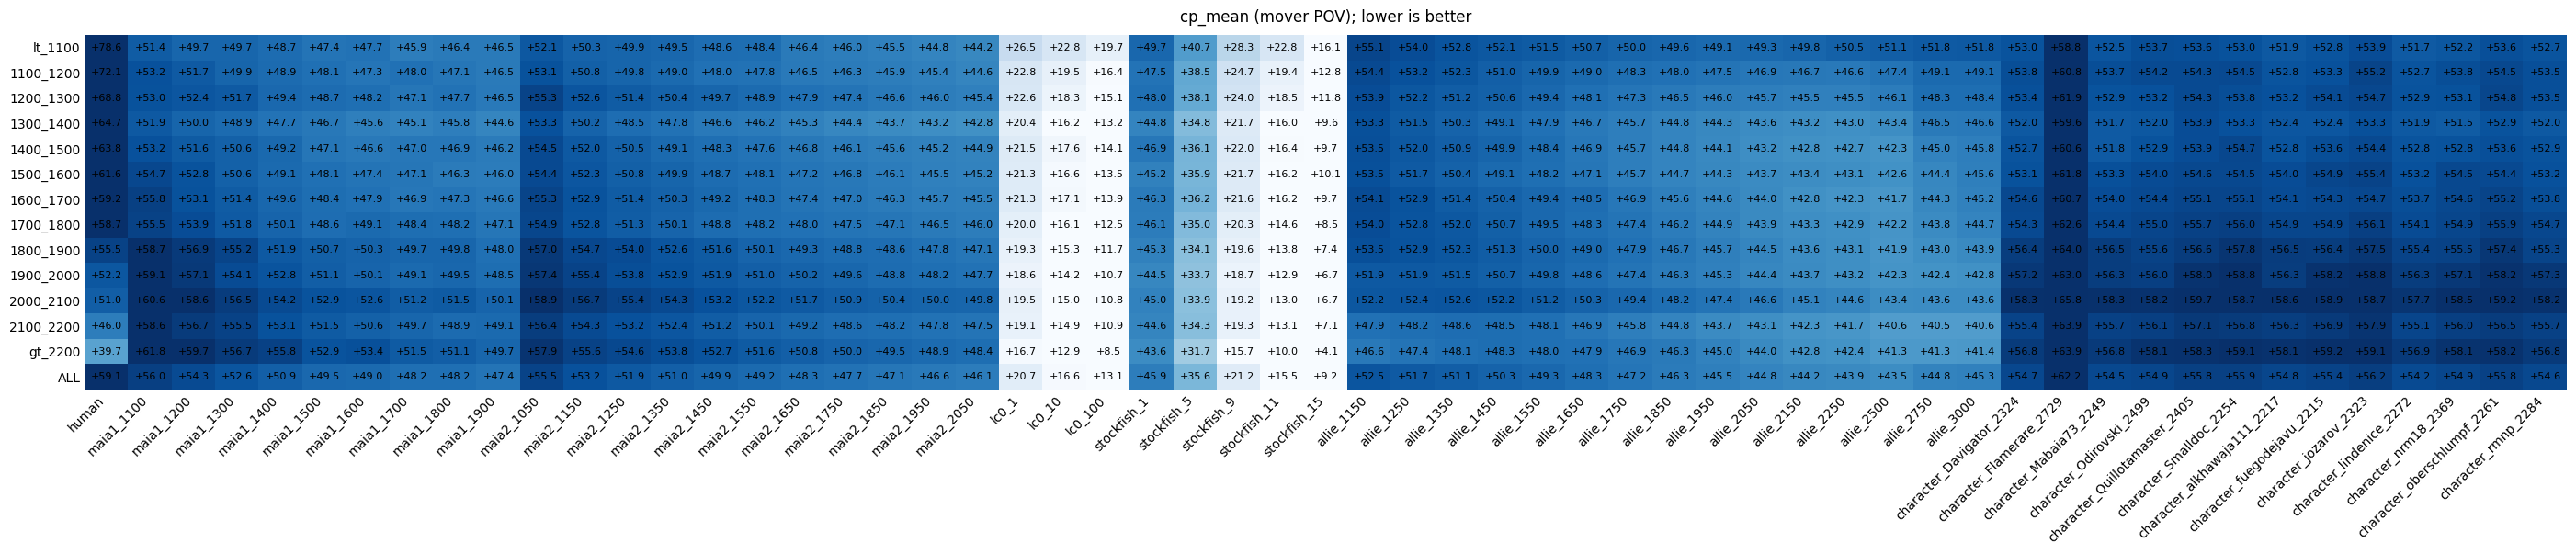

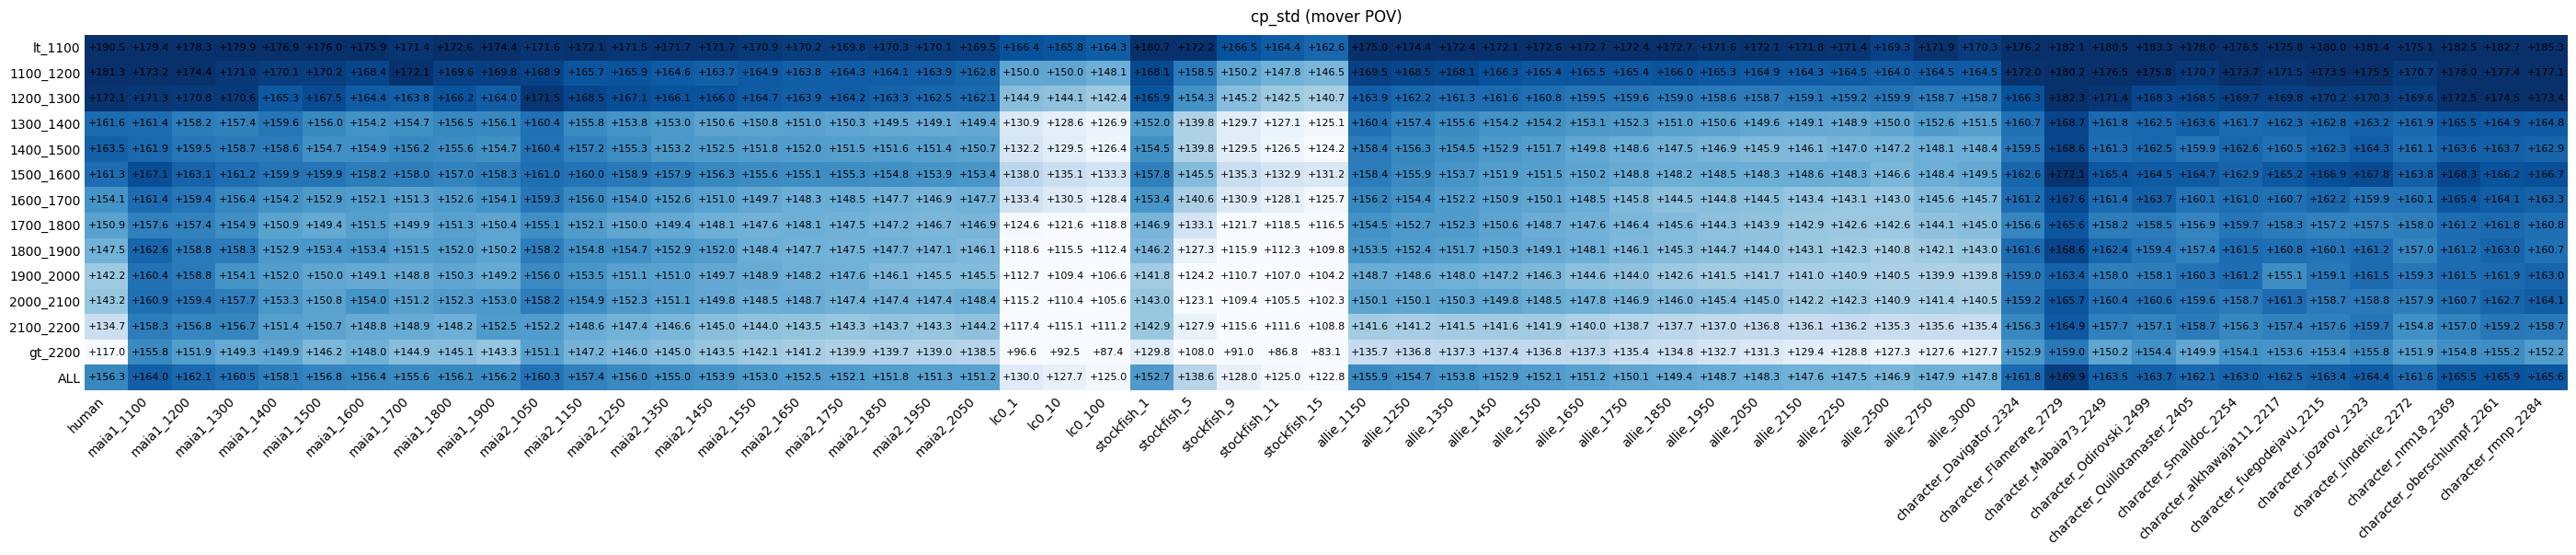

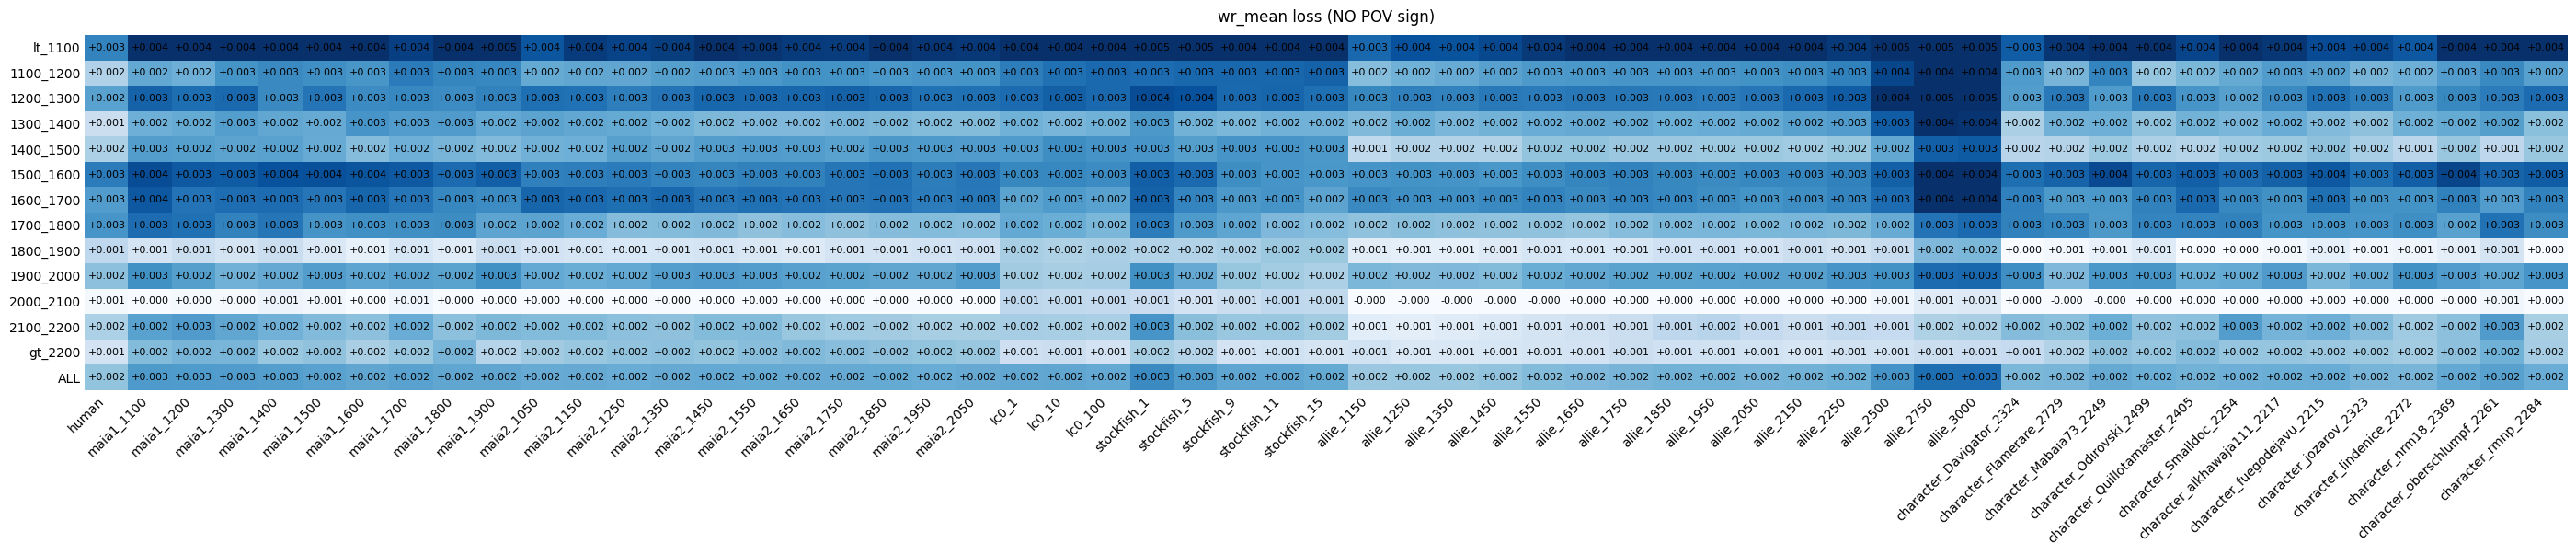

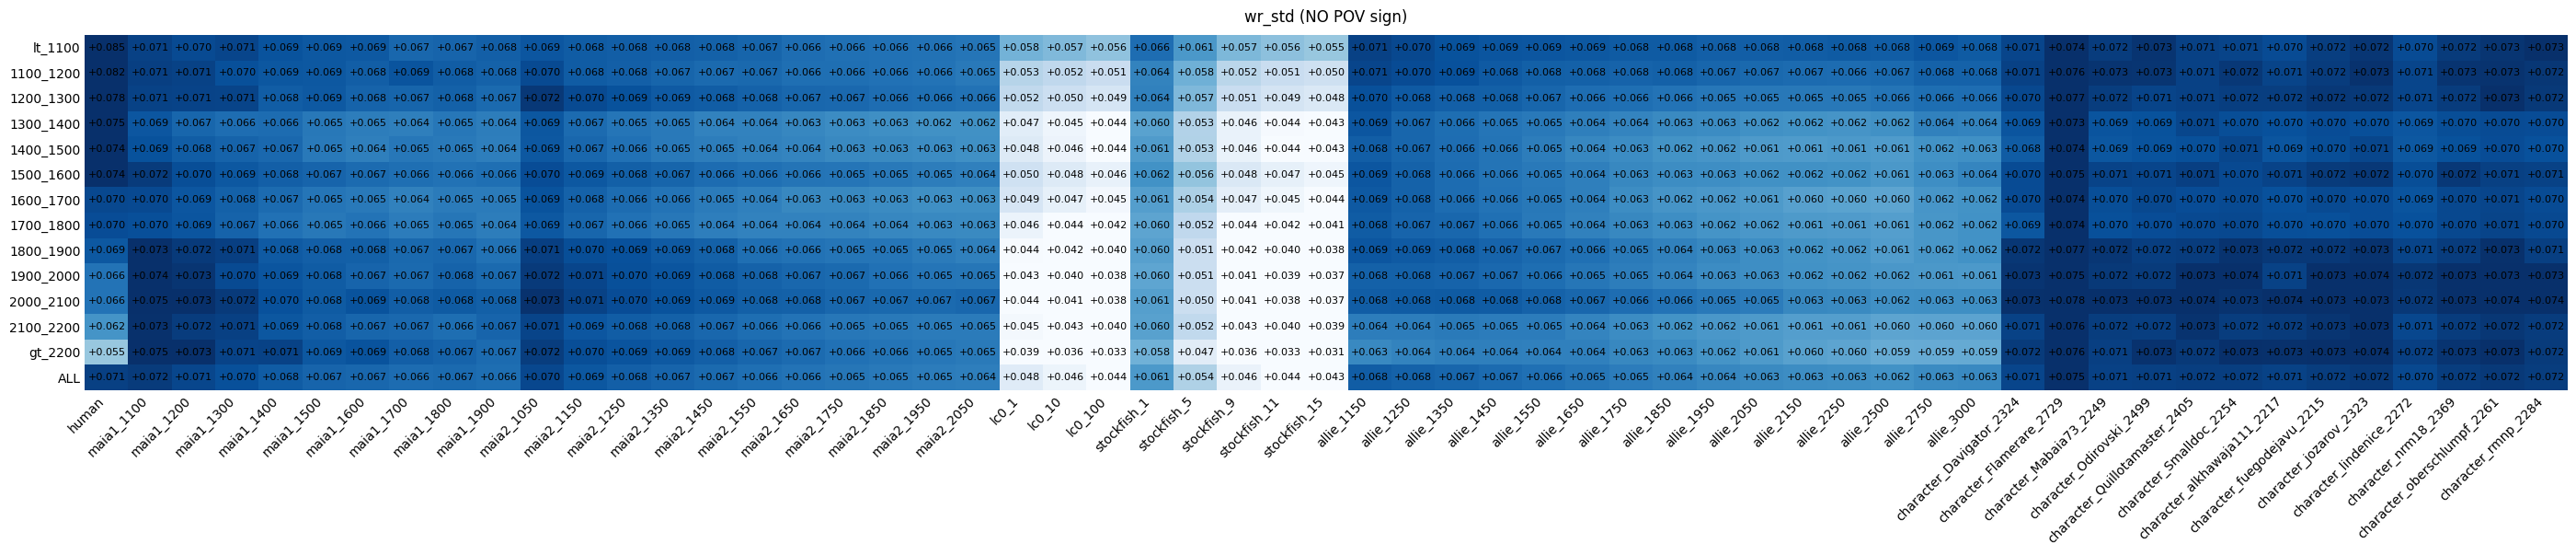

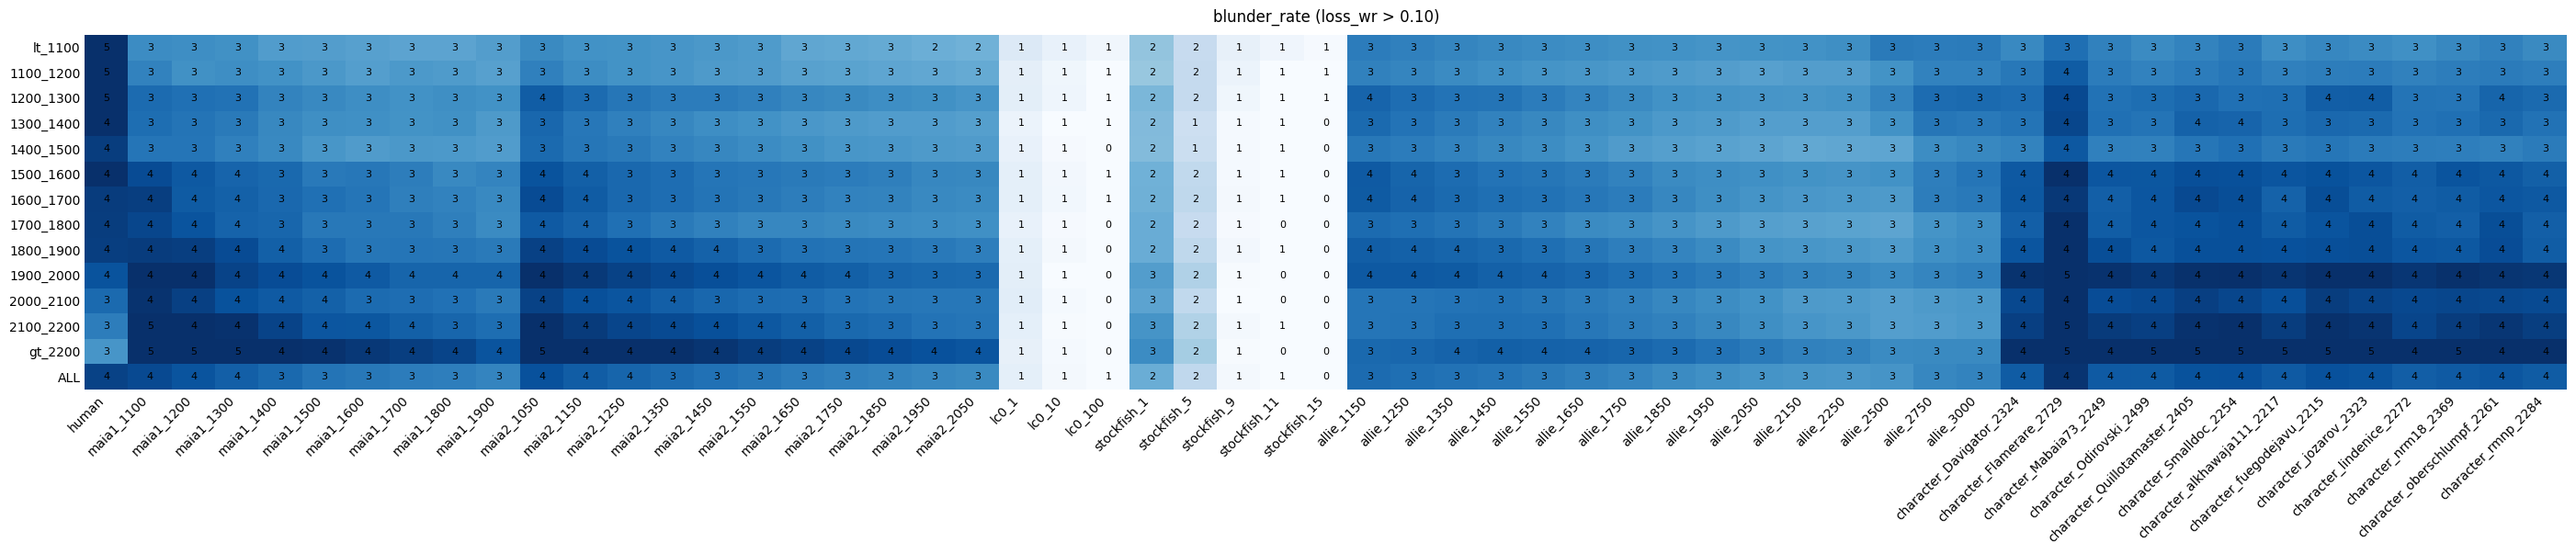

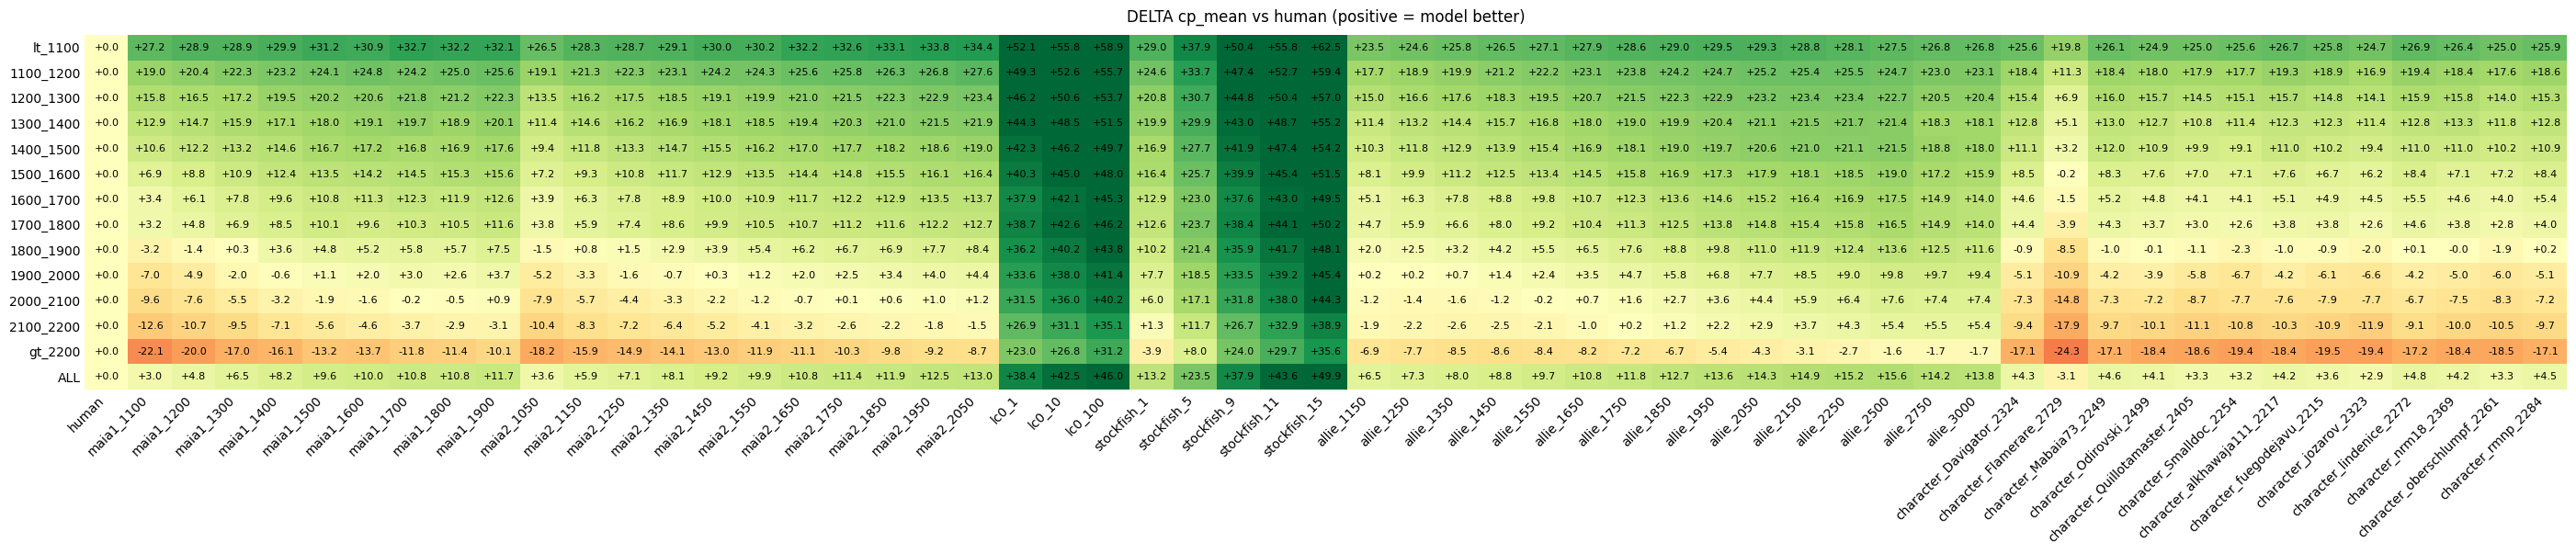

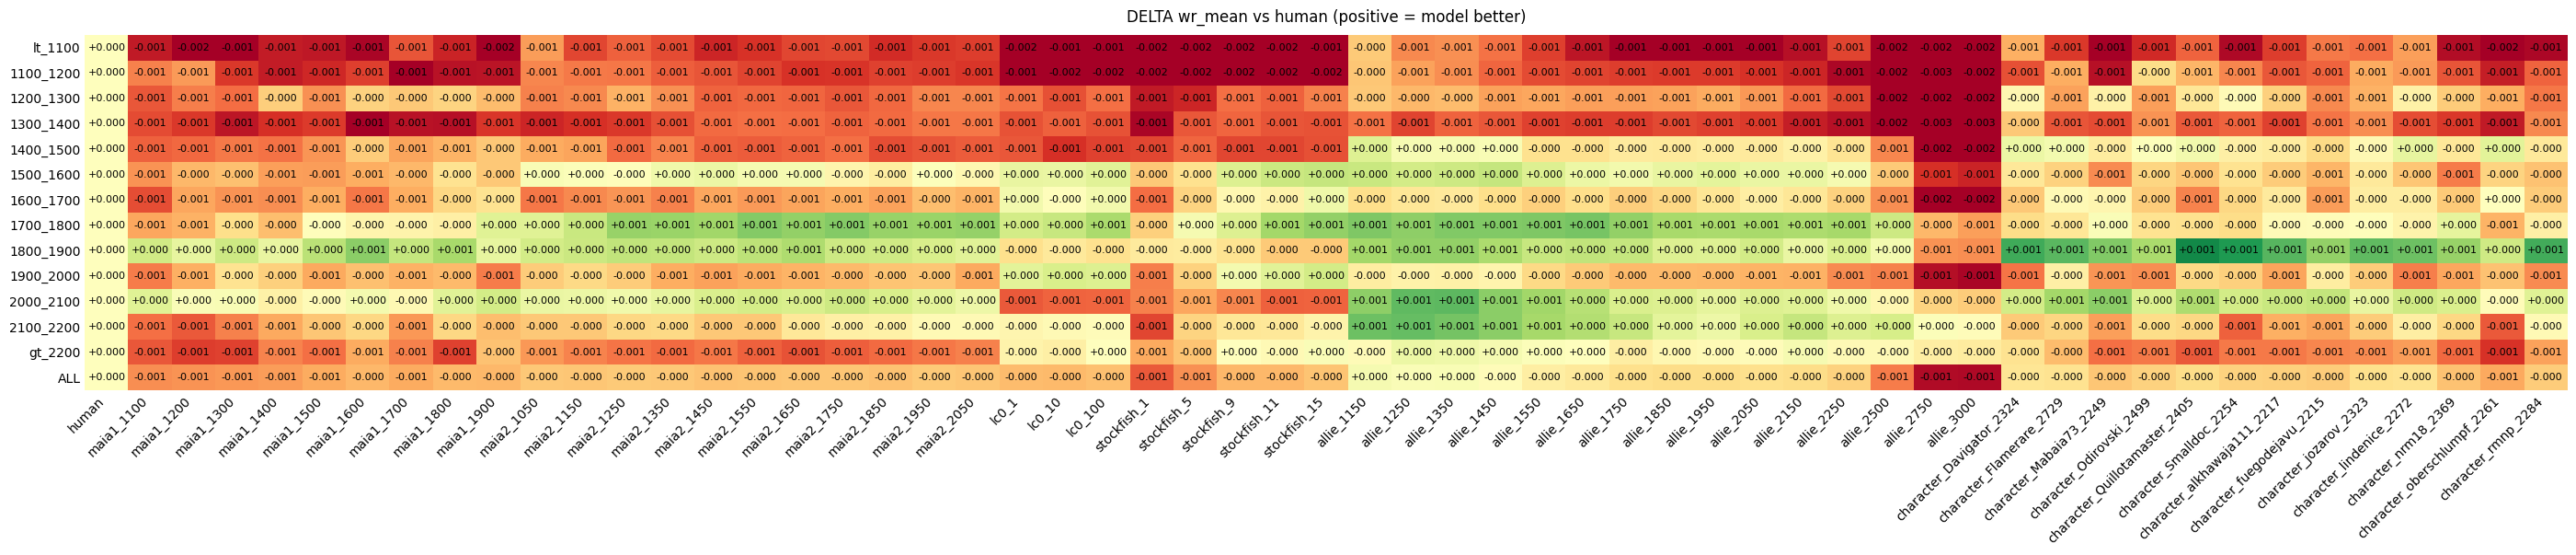

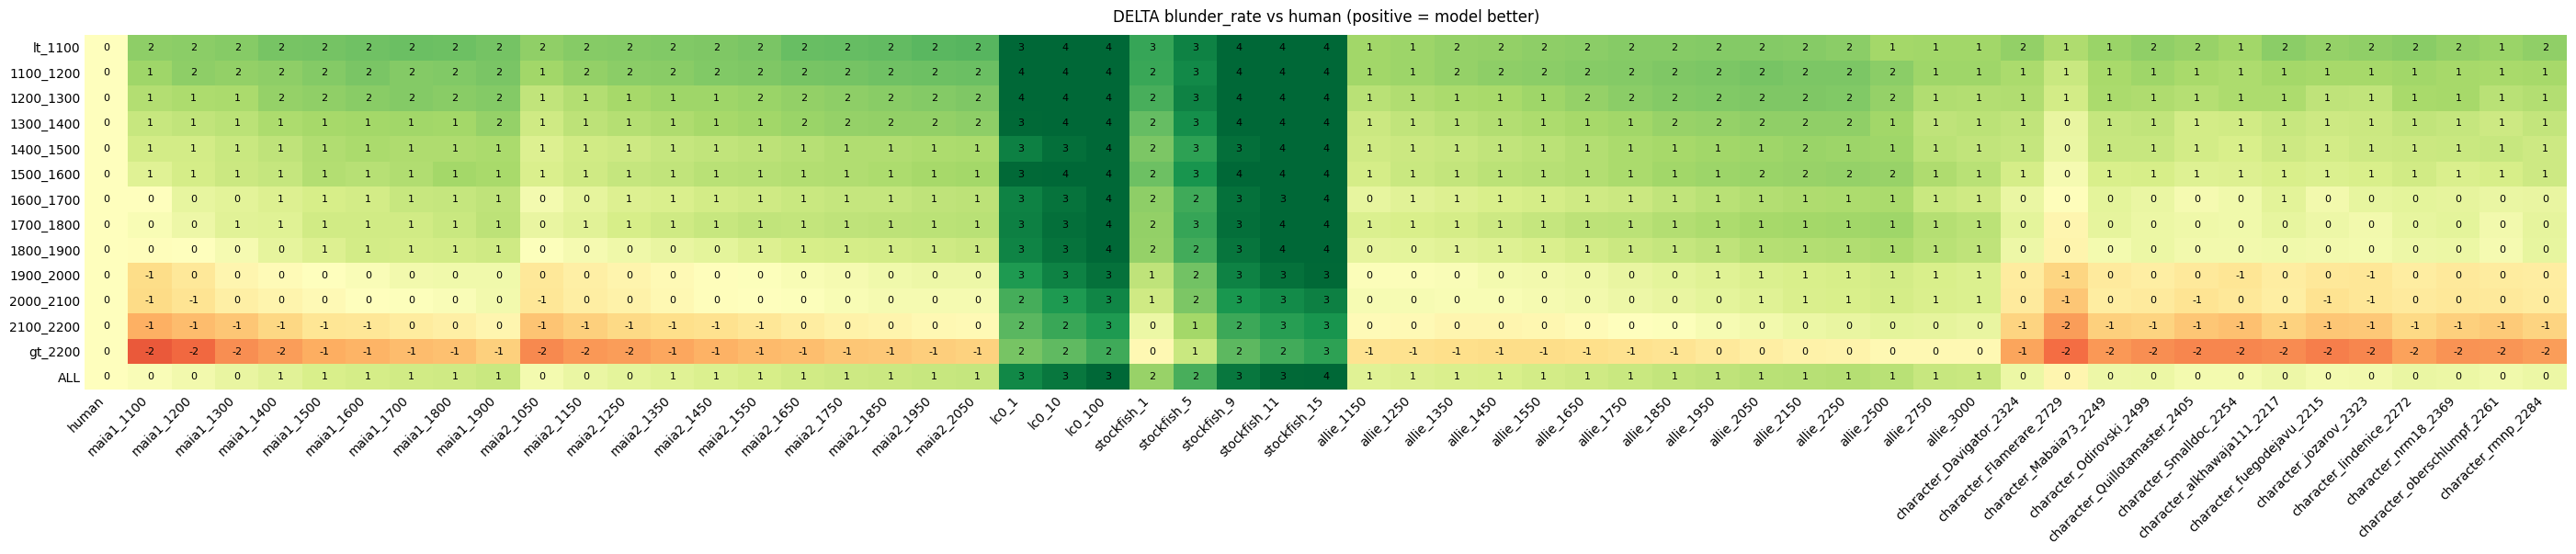

In [12]:
# === Heatmaps ===
plot_metric_heatmap(tables["cp_mean"], title="cp_mean (mover POV); lower is better", out_path=OUT_DIR/"heatmap_cp_mean.png", fmt="cp", cmap="Blues")
plot_metric_heatmap(tables["cp_std"],  title="cp_std (mover POV)", out_path=OUT_DIR/"heatmap_cp_std.png", fmt="cp", cmap="Blues")

plot_metric_heatmap(tables["wr_mean"], title="wr_mean loss (NO POV sign)", out_path=OUT_DIR/"heatmap_wr_mean.png", fmt="pp", cmap="Blues")
plot_metric_heatmap(tables["wr_std"],  title="wr_std (NO POV sign)", out_path=OUT_DIR/"heatmap_wr_std.png", fmt="pp", cmap="Blues")

plot_metric_heatmap(tables["blunder_rate"], title="blunder_rate (loss_wr > 0.10)", out_path=OUT_DIR/"heatmap_blunder_rate.png", fmt="pct", cmap="Blues")

plot_metric_heatmap(delta_tables["cp_mean_delta"], title="DELTA cp_mean vs human (positive = model better)", out_path=OUT_DIR/"heatmap_cp_mean_delta.png", fmt="cp", cmap="RdYlGn", center=0.0)
plot_metric_heatmap(delta_tables["wr_mean_delta"], title="DELTA wr_mean vs human (positive = model better)", out_path=OUT_DIR/"heatmap_wr_mean_delta.png", fmt="pp", cmap="RdYlGn", center=0.0)
plot_metric_heatmap(delta_tables["blunder_rate_delta"], title="DELTA blunder_rate vs human (positive = model better)", out_path=OUT_DIR/"heatmap_blunder_rate_delta.png", fmt="pct", cmap="RdYlGn", center=0.0)